# RiceLeaf — Data Analysis Report

**Project ID:** PRCP-1001  
**Topic:** Rice Leaf Disease Classification  
**Date:** September 3, 2025

## Executive Summary

This report presents an exploratory study and modeling plan for the RiceLeaf dataset, which contains 120 labeled images of rice leaves affected by three common diseases: Leaf Smut, Brown Spot, and Bacterial Leaf Blight (40 images per class). The small and balanced dataset size creates challenges for training deep networks from scratch, making transfer learning and careful augmentation essential.

**Key Insights:**
- Dataset is small (120 images total), so direct training may cause overfitting.
- Class distribution is balanced (40 per class), which avoids class imbalance issues.
- Recommended strategy: apply transfer learning with pretrained CNNs ,and use data augmentation.
- Deliverables: EDA notebook, preprocessing workflow, augmentation pipeline and, evaluation metrics, and final packaged model.

In [3]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.utils import to_categorical
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dropout
import warnings
warnings.filterwarnings("ignore")

## 1. Dataset Overview

- **Total images:** 120
- **Classes:** 3 (`Leaf Smut`, `Brown Spot`, `Bacterial Leaf Blight`)
- **Per-class samples:** 40
- **File type:** JPG
- **Suggested folder structure:**

```
RiceLeaf/
├── Leaf_smut/ (40 images)
├── Brown_spot/ (40 images)
└── Bacterial_leaf_blight/ (40 images)m

In [4]:
data = r"C:\Users\Asus\Desktop\Capstone Project\Rice Leaf Detection\PRCP-1001-RiceLeaf\Data"

## 2. Data Integrity and Quality Checks

Before training, ensure the dataset is clean and consistent. Suggested checks include:

1. Verify counts per class.
2. Identify any corrupted or unreadable files.
3. Inspect image dimensions and color modes.
4. Remove duplicates.


## 3. Exploratory Visualizations

Suggested visualizations for understanding the dataset:
- Sample grid of images per class.
- Histogram of image widths and heights.
- Aspect ratio distribution.
- Augmentation preview (flips, rotations, brightness changes).

## 4. Preprocessing Workflow

1. Remove duplicates or corrupted files.
2. Convert all images to RGB format.
3. Resize to a consistent input size.
4. Normalize pixel values using either:
   - `[0,1]` scaling with dataset mean/std, or
   - Built-in preprocessing functions.

## 5. Data Augmentation Strategy

Since the dataset is small, augmentation is critical to prevent overfitting. Suggested augmentations:
- Horizontal/vertical flips (if biologically valid).
- Random rotations (20–45°).
- Zoom and random crops.
- Brightness and contrast adjustments.
- Minor blur or sharpening.
- Width/height translations.

In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,       # 0-20 degree rotate
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    data,
    target_size=(150 ,150),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    color_mode="rgb"
)

val_generator = datagen.flow_from_directory(
    data,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    color_mode="rgb"
)


Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.


## 6. Modeling Plan

### Baselines
- **Simple baseline:** Logistic regression on flattened downsampled images.
- **Small CNN:** Basic convolutional model to test overfitting behavior.

### Recommended
- **Transfer Learning:** Use pretrained MobileNetV2.
- Steps:
  1. Freeze base model layers.
  2. Add pooling and dropout layers.
  3. Train final dense layer.
  4. Unfreeze top layers for fine-tuning with a lower learning rate.


In [6]:
model = Sequential()

# 1st Conv layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D((2,2)))
Dropout(0.25)

# 2nd Conv layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
Dropout(0.25)

# Flatten and Dense layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(3, activation='softmax'))
Dropout(0.5)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 82944)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      10,616,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,636,739 (40.58 MB)

 Trainable params: 10,636,739 (40.58 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Evaluation Strategy

- **Validation split:** 80% train / 20% validation.
- **Alternative:** Stratified 5-fold cross-validation for more reliable estimates.
- **Metrics:** Accuracy, precision, recall, F1-score, and confusion matrix.

**Expected performance:**
- Random guess baseline: ~33% accuracy.
- Small CNN: ~60–70% (likely overfit).
- Transfer learning: ~75–90% (with augmentation).

In [7]:
history = model.fit(
        train_generator, 
        epochs=20, 
        validation_data =val_generator
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 698ms/step - accuracy: 0.3333 - loss: 8.7025 - val_accuracy: 0.3478 - val_loss: 2.7826
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 564ms/step - accuracy: 0.3333 - loss: 1.9790 - val_accuracy: 0.3478 - val_loss: 1.1549
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 561ms/step - accuracy: 0.3958 - loss: 1.1030 - val_accuracy: 0.4348 - val_loss: 0.9814
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 548ms/step - accuracy: 0.6354 - loss: 0.9272 - val_accuracy: 0.7391 - val_loss: 0.7794
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 743ms/step - accuracy: 0.6354 - loss: 0.8887 - val_accuracy: 0.6957 - val_loss: 0.6770
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 569ms/step - accuracy: 0.6250 - loss: 0.7659 - val_accuracy: 0.9130 - val_loss: 0.6314
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 545ms/step - accuracy: 0.8021 - loss: 0.6407 - val_accuracy: 0.6087 - val_loss: 0.8726
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 523ms/step - accuracy: 0.7292 - loss: 0.5876 - val_accuracy: 0.5652 - val_loss:

In [42]:
test_loss, test_acc = model.evaluate(train_generator)
print("Test Accuracy:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 1.0000 - loss: 0.0165
Test Accuracy: 0.016516612842679024


In [44]:
test_loss, test_acc = model.evaluate(train_generator)
print("Test Accuracy:", test_acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step - accuracy: 1.0000 - loss: 0.0165
Test Accuracy: 1.0


In [46]:
test_loss, test_acc = model.evaluate(val_generator)
print("Test Accuracy:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.7391 - loss: 0.5970
Test Accuracy: 0.5970228910446167


In [48]:
test_loss, test_acc = model.evaluate(val_generator)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.7391 - loss: 0.5970
Test Accuracy: 0.739130437374115


## 8. Model Explainability

To interpret predictions, use:
- Grad-CAM
- Integrated Gradients

This helps visualize which parts of the leaf images influence classification decisions.

In [50]:
x_batch, y_batch = next(train_generator)
index = 0
image = x_batch[index]
true_label = np.argmax(y_batch[index])
prediction = model.predict(np.expand_dims(image, axis=0))
predicted_label = np.argmax(prediction)
print("Predicted Label:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Label: 1


In [52]:
x_batch, y_batch = next(val_generator)
index = 0
image = x_batch[index]
true_label = np.argmax(x_batch[index])
prediction = model.predict(np.expand_dims(image, axis=0))
predicted_label = np.argmax(prediction)
print("Predicted Label:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Label: 2


In [54]:
!pip install matplotlib

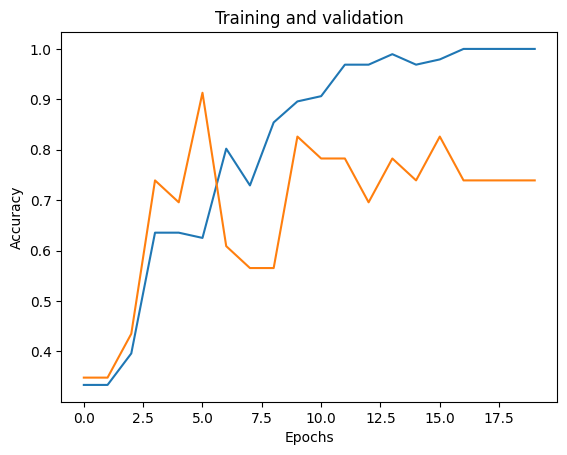

In [56]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"],label="Training accuracy")
plt.plot(history.history["val_accuracy"],label="valdiation accuracy")
plt.title("Training and validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

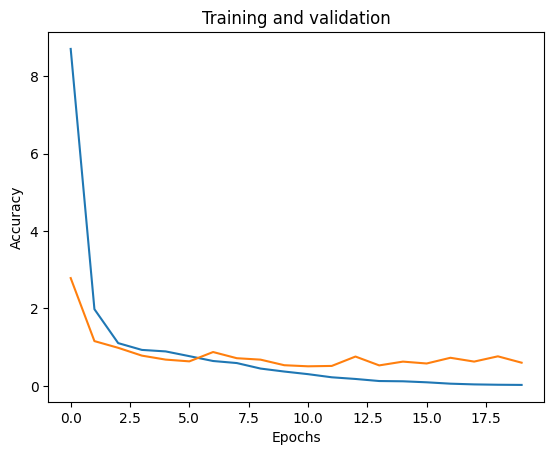

In [58]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label="valdiation loss")
plt.title("Training and validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

## 9. Deployment Plan

- Save trained model in `SavedModel` format.
- Provide inference script to load a model, preprocess input, and output predictions.
- Optional: Build a lightweight Flask or FastAPI app for user interaction.

In [79]:
from tensorflow.keras.models import load_model
model.save("rice_disease_model.h5")
print(" Model saved as rice_disease_model.h5")

 Model saved as rice_disease_model.h5


In [81]:
loaded_model = load_model("rice_disease_model.h5")
print(" Model loaded successfully")

 Model loaded successfully


In [83]:
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 82944)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      10,616,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,636,741 (40.58 MB)

 Trainable params: 10,636,739 (40.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## 10. Recommended Next Steps

1. Perform dataset integrity checks.
2. Generate exploratory plots and augmentation previews.
3. Train transfer learning model.
4. Evaluate using cross-validation.
5. Fine-tune with EfficientNet for comparison.
6. Produce Grad-CAM visualizations for both correct and misclassified samples.
7. Collect more images or apply advanced augmentations for improved performance.

In [85]:
loss, acc = loaded_model.evaluate(train_generator)
print(f"Test Accuracy after loading: {acc*100:.2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 1.0000 - loss: 0.0165
Test Accuracy after loading: 100.00%


## 11. Environment & Setup

**Requirements:**
- Python 3.8+
- TensorFlow 2.11+
- Pillow, NumPy, Matplotlib, scikit-learn, Albumentations (optional), tf-keras-vis (optional)

**Install packages:**
```bash
pip install tensorflow pillow numpy matplotlib scikit-learn albumentations
```

**Unzip dataset:**
```bash
unzip PRCP-1001-RiceLeaf.zip -d RiceLeaf

## Closing Note

This structured plan outlines the end-to-end pipeline — from dataset validation and visualization to model training and deployment. The next milestone is to implement EDA scripts and start with transfer learning experiments.

---

*End of Report*